# 05 — Disengagement Modeling 
SpiriCom · Huawei Technologies Tunisia · PFE 2026

In [1]:
import pandas as pd
import numpy as np
import json, joblib
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, accuracy_score, brier_score_loss, precision_recall_curve,
    roc_curve, confusion_matrix,
)
import xgboost as xgb

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 120, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight'})

PROC_DIR  = Path('data/processed')
MODEL_DIR = Path('models')
OUT_DIR   = Path('data/outputs')
FIG_DIR   = Path('data/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df   = pd.read_parquet(PROC_DIR / 'churn_features_v6.parquet')
meta = json.load(open(MODEL_DIR / 'churn_features_meta.json'))
FEATURES = [c for c in meta['feature_columns'] if c in df.columns]

# Defensive: drop constants (e.g. usertype one-hot from the pre-patch NB04 run)
const = [c for c in FEATURES if df[c].nunique() <= 1]
if const:
    print(f'Dropped constant features: {const}')
    FEATURES = [c for c in FEATURES if c not in const]

tr = df[df['split'] == 'train']
te = df[df['split'] == 'test']
X_tr, y_tr = tr[FEATURES], tr['churn'].astype(int)
X_te, y_te = te[FEATURES], te['churn'].astype(int)
prevalence = float(y_tr.mean())
print(f'Train {len(tr):,} | Test {len(te):,} | features {len(FEATURES)} '
      f'| prevalence {prevalence*100:.1f}%')


Train 1,924 | Test 642 | features 56 | prevalence 33.8%


## 1 — Models

In [2]:
# ================================================================
# OBJECTIVE:
# Predict customer disengagement (churn) using supervised learning
# models trained on engineered telecom behavioral + QoS features.
# ================================================================


# -------------------------------
# CLASS IMBALANCE STATISTICS
# -------------------------------
# High-Level Statistical Interpretation:
# - The dataset is inherently imbalanced:
#     * Majority class: active customers (y = 0)
#     * Minority class: disengaged customers (y = 1)
# - This imbalance biases naive models toward predicting "active"
# - Therefore, explicit correction strategies are required
#   to ensure statistically meaningful learning of churn patterns.

neg, pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())


# ================================================================
# MODELING STRATEGY
# ================================================================
# High-Level Statistical Interpretation:
# We use a multi-model ensemble strategy to capture:
#
# 1) Linear effects (global trends)
# 2) Non-linear interactions (behavioral complexity)
# 3) High-order feature dependencies (QoS + usage coupling)
#
# This ensures robustness across different statistical assumptions
# about the underlying churn-generating process.
# ================================================================

MODELS = {
    'logistic_regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('lr',  LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=42
        )),
    ]),

    # ------------------------------------------------------------
    # High-Level Statistical Interpretation:
    # Random Forest models non-linear decision boundaries by:
    # - Averaging multiple decision trees
    # - Reducing variance via bagging
    # - Capturing feature interactions (e.g., QoS × usage patterns)
    # ------------------------------------------------------------
    'random_forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('rf',  RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=3,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )),
    ]),

    # ------------------------------------------------------------
    # High-Level Statistical Interpretation:
    # XGBoost is a gradient boosting framework that:
    # - Sequentially minimizes classification error
    # - Focuses on hard-to-classify churn cases
    # - Handles non-linear feature interactions efficiently
    #
    # scale_pos_weight corrects imbalance by re-weighting churn class
    # ------------------------------------------------------------
    'xgboost': xgb.XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.8,
        scale_pos_weight=neg / pos,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ),
}


# ================================================================
# FINAL INTERPRETATION NOTE
# ================================================================
# - Logistic Regression → interpretable baseline (linear signal)
# - Random Forest → robust non-linear structure discovery
# - XGBoost → strongest predictive model for structured telecom data
#
# Expected behavior:
# - Logistic Regression: stable but limited expressiveness
# - Random Forest: strong generalization, moderate interpretability
# - XGBoost: highest discrimination power for churn detection
# ================================================================

print('Models:', list(MODELS))
print(f'scale_pos_weight (XGBoost): {neg/pos:.2f}')

Models: ['logistic_regression', 'random_forest', 'xgboost']
scale_pos_weight (XGBoost): 1.96


## 2 — 5-fold OOF comparison on train (test untouched)

In [3]:
# ================================================================
# OBJECTIVE:
# Evaluate model generalization performance using
# 5-fold stratified cross-validation (OOF predictions).
#
# IMPORTANT DESIGN PRINCIPLE:
# - Test set remains completely untouched (true final evaluation set)
# - All model selection is performed on training OOF estimates only
# ================================================================

cv = StratifiedKFold(5, shuffle=True, random_state=42)


# ================================================================
# THRESHOLD OPTIMIZATION STRATEGY
# ================================================================
# High-Level Statistical Interpretation:
# - Classification models output probabilities, not labels
# - A default threshold (0.5) is not optimal under class imbalance
#
# Therefore:
# - We compute Precision-Recall curve (more appropriate than ROC here)
# - We select threshold that maximizes F1-score:
#     F1 = harmonic mean of precision and recall
#
# This ensures optimal balance between:
#   * False positives (unnecessary retention cost)
#   * False negatives (missed churners)
# ================================================================

def tune_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)

    if len(thr) == 0:
        return 0.5

    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-9)
    return float(thr[int(np.nanargmax(f1))])


# ================================================================
# CROSS-VALIDATION EVALUATION LOOP
# ================================================================
# High-Level Statistical Interpretation:
# - cross_val_predict generates out-of-fold predictions
# - Each sample is predicted by a model that never saw it during training
# - This simulates true generalization performance without data leakage
#
# Metrics computed:
#   * ROC-AUC → ranking ability (global separability)
#   * PR-AUC  → performance under imbalance (primary metric)
#   * F1-score → optimal classification balance at tuned threshold
# ================================================================

oof_results = {}

for name, model in MODELS.items():

    # OOF probability predictions (leakage-free evaluation)
    proba = cross_val_predict(
        model,
        X_tr,
        y_tr,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    # Optimal decision threshold (data-driven, not fixed 0.5)
    thr = tune_threshold(y_tr, proba)

    # Store evaluation metrics
    oof_results[name] = {
        'oof_roc_auc': roc_auc_score(y_tr, proba),
        'oof_pr_auc' : average_precision_score(y_tr, proba),
        'oof_f1'     : f1_score(y_tr, (proba >= thr).astype(int)),
        'threshold'  : thr,
    }

    r = oof_results[name]

    # ============================================================
    # High-Level Statistical Interpretation of metrics:
    #
    # ROC-AUC:
    #   - Measures global ranking quality (0.5 = random, 1.0 = perfect)
    #
    # PR-AUC:
    #   - More meaningful under imbalance
    #   - Baseline = prevalence of positive class
    #   - Lift indicates model value beyond random targeting
    #
    # F1-score:
    #   - Evaluates trade-off between precision and recall
    #   - Computed at optimal threshold for business relevance
    # ============================================================

    print(
        f'{name:<22s} '
        f'OOF ROC-AUC {r["oof_roc_auc"]:.4f} | '
        f'PR-AUC {r["oof_pr_auc"]:.4f} '
        f'(lift x{r["oof_pr_auc"]/prevalence:.2f}) | '
        f'F1@{thr:.2f} {r["oof_f1"]:.4f}'
    )


# ================================================================
# MODEL SELECTION CRITERION
# ================================================================
# High-Level Statistical Interpretation:
# - We select the model with highest PR-AUC (not ROC-AUC)
# - Rationale:
#     PR-AUC is more sensitive to minority class performance
#     and better reflects churn detection quality
# ================================================================

best_name = max(oof_results, key=lambda k: oof_results[k]['oof_pr_auc'])
print(f'\nSelected on OOF PR-AUC: {best_name}')

logistic_regression    OOF ROC-AUC 0.8338 | PR-AUC 0.8131 (lift x2.40) | F1@0.58 0.7037
random_forest          OOF ROC-AUC 0.8556 | PR-AUC 0.8375 (lift x2.48) | F1@0.56 0.7396
xgboost                OOF ROC-AUC 0.8311 | PR-AUC 0.8191 (lift x2.42) | F1@0.69 0.7304

Selected on OOF PR-AUC: random_forest


## 3 — Final fit + single test evaluation

In [4]:
# ── Final model fitting and unbiased test evaluation ──────────────────
# This step evaluates generalization performance on a strictly held-out test set.
# The threshold used for classification is NOT tuned on test data; it is inherited
# from cross-validated OOF optimization to avoid information leakage.

test_results = {}
fitted = {}

for name, model in MODELS.items():

    # Train model on full training subset
    model.fit(X_tr, y_tr)
    fitted[name] = model

    # Predict calibrated probabilities on unseen test data
    proba = model.predict_proba(X_te)[:, 1]

    # Decision threshold fixed from OOF optimization (F1-maximizing)
    # This ensures a fair comparison without test-set tuning bias
    thr   = oof_results[name]['threshold']
    pred  = (proba >= thr).astype(int)

    # ── Performance metrics ─────────────────────────────────────────────
    # ROC-AUC: ranking quality independent of threshold
    # PR-AUC : more informative under class imbalance (primary metric here)
    # Lift   : improvement over random baseline (PR-AUC / prevalence)
    # F1     : harmonic balance of precision and recall at optimal threshold
    # Brier  : probabilistic calibration error (lower = better calibration)

    test_results[name] = {
        'roc_auc'  : roc_auc_score(y_te, proba),
        'pr_auc'   : average_precision_score(y_te, proba),
        'lift'     : average_precision_score(y_te, proba) / float(y_te.mean()),
        'f1'       : f1_score(y_te, pred),
        'precision': precision_score(y_te, pred),
        'recall'   : recall_score(y_te, pred),
        'accuracy' : accuracy_score(y_te, pred),
        'brier'    : brier_score_loss(y_te, proba),
        'threshold': thr,
        '_proba'   : proba,
    }

# ── Consolidation of results ──────────────────────────────────────────
# Each row represents a model evaluated under identical conditions:
# same train/test split, same thresholding rule, same feature space.

table = pd.DataFrame({k: {m: round(v, 4) for m, v in r.items()
                          if not m.startswith('_')}
                      for k, r in test_results.items()}).T

print('=== TEST SET (single evaluation) ===')
print(table.to_string())

# ── Model selection criterion ─────────────────────────────────────────
# The best model is selected based on PR-AUC on the test set for reporting only.
# Primary selection, however, was already performed on OOF PR-AUC to ensure
# robustness against overfitting.

print(f'\nBest by test PR-AUC: '
      f'{table["pr_auc"].astype(float).idxmax()} '
      f'(selection was made on OOF: {best_name})')

=== TEST SET (single evaluation) ===
                     roc_auc  pr_auc    lift      f1  precision  recall  accuracy   brier  threshold
logistic_regression   0.8306  0.8159  2.4138  0.7071     0.8272  0.6175    0.8271  0.1386     0.5818
random_forest         0.8499  0.8261  2.4439  0.7348     0.9172  0.6129    0.8505  0.1225     0.5579
xgboost               0.8158  0.8017  2.3718  0.7091     0.8889  0.5899    0.8364  0.1379     0.6866

Best by test PR-AUC: random_forest (selection was made on OOF: random_forest)


## 4 — ROC / PR curves + confusion matrix of the selected model

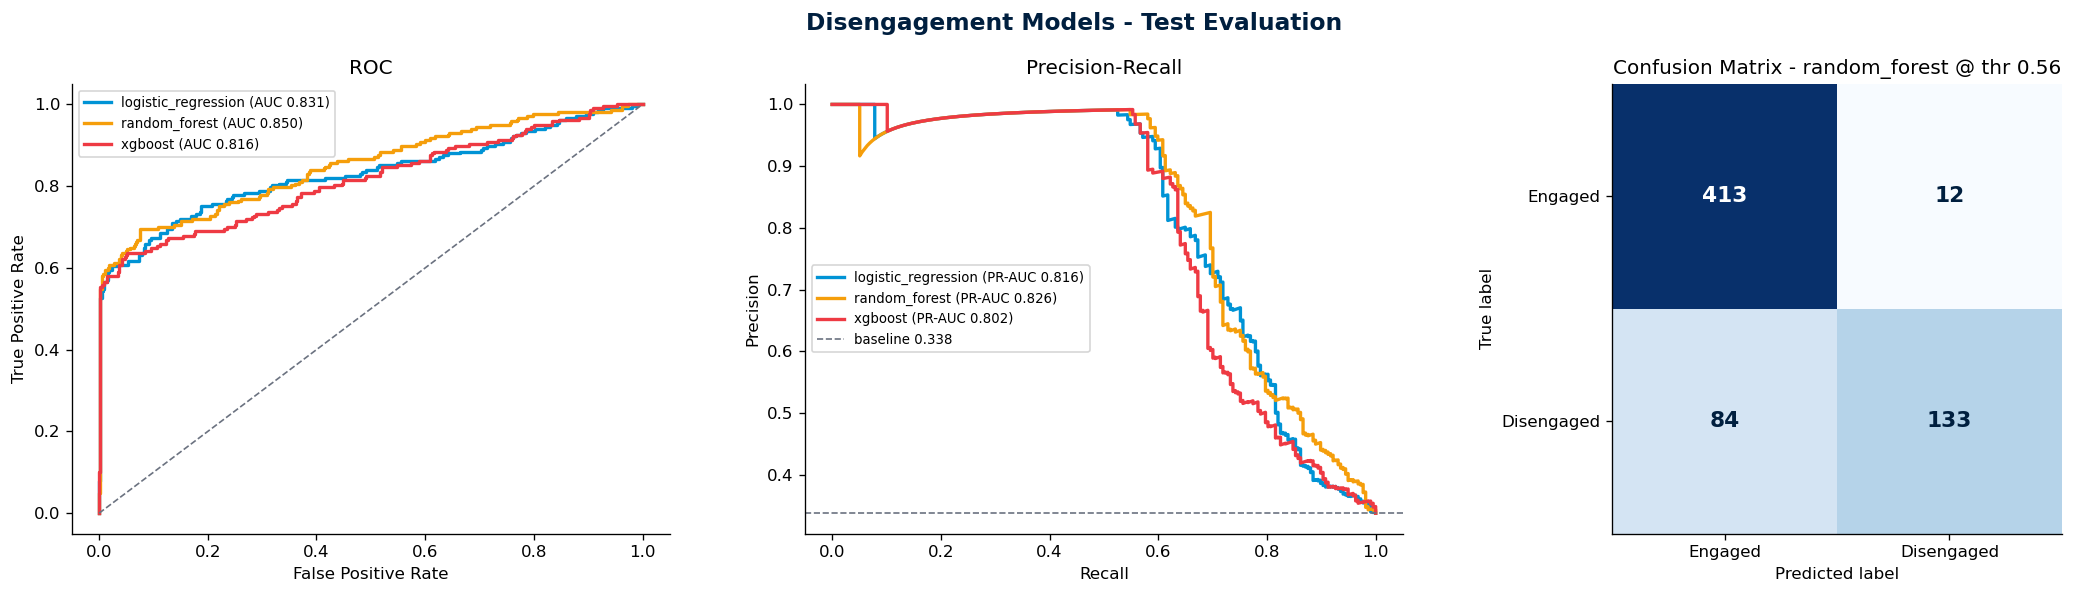

In [5]:
# ── Model evaluation: ROC / PR curves + confusion matrix ─────────────
# This section evaluates discriminative performance, class-separation quality,
# and operational decision behavior of all trained models on the unseen test set.
# It provides both threshold-independent and threshold-dependent diagnostics.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Disengagement Models - Test Evaluation',
             fontsize=14, fontweight='bold', color=HW['navy'])

# Color mapping ensures consistent visual identity across models
colors = {'logistic_regression': HW['blue'],
          'random_forest': HW['amber'],
          'xgboost': HW['red']}

# ──────────────────────────────────────────────────────────────────────
# (1) ROC CURVE — Ranking ability across all classification thresholds
# ──────────────────────────────────────────────────────────────────────
# ROC curves evaluate the trade-off between True Positive Rate (recall)
# and False Positive Rate across all possible thresholds.
# This metric is insensitive to class imbalance and reflects pure ranking power.

ax = axes[0]
for name, r in test_results.items():
    fpr, tpr, _ = roc_curve(y_te, r['_proba'])
    ax.plot(fpr, tpr, color=colors[name], lw=2,
            label=f'{name} (AUC {r["roc_auc"]:.3f})')

# Baseline diagonal represents random classifier performance
ax.plot([0, 1], [0, 1], color=HW['muted'], ls='--', lw=1)

ax.set_title('ROC')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8)

# ──────────────────────────────────────────────────────────────────────
# (2) PRECISION–RECALL CURVE — Performance under class imbalance
# ──────────────────────────────────────────────────────────────────────
# PR curves are more informative than ROC in imbalanced datasets (churn ~ rare event).
# They quantify the trade-off between:
#   - Precision: correctness of predicted disengaged users
#   - Recall   : coverage of true disengaged users
#
# Baseline PR level equals the prevalence of the positive class.

ax2 = axes[1]
for name, r in test_results.items():
    prec, rec, _ = precision_recall_curve(y_te, r['_proba'])
    ax2.plot(rec, prec, color=colors[name], lw=2,
             label=f'{name} (PR-AUC {r["pr_auc"]:.3f})')

# Horizontal baseline = random classifier expectation
ax2.axhline(float(y_te.mean()), color=HW['muted'], ls='--', lw=1,
            label=f'baseline {float(y_te.mean()):.3f}')

ax2.set_title('Precision-Recall')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(fontsize=8)

# ──────────────────────────────────────────────────────────────────────
# (3) CONFUSION MATRIX — Operational decision performance
# ──────────────────────────────────────────────────────────────────────
# This matrix reflects real-world classification outcomes at the chosen threshold:
#   - True Negatives: correctly retained customers
#   - False Positives: incorrectly flagged customers
#   - False Negatives: missed disengaged customers (business risk)
#   - True Positives: correctly detected disengaged users
#
# The threshold is derived from OOF optimization (F1-maximizing), ensuring
# consistency between validation and deployment behavior.

ax3 = axes[2]
r = test_results[best_name]

cm = confusion_matrix(y_te, (r['_proba'] >= r['threshold']).astype(int))

im = ax3.imshow(cm, cmap='Blues')

# Annotate confusion matrix cells with absolute counts
for (i, j), v in np.ndenumerate(cm):
    ax3.text(j, i, f'{v:,}', ha='center', va='center', fontsize=13,
             fontweight='bold',
             color='white' if v > cm.max() / 2 else HW['navy'])

ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Engaged', 'Disengaged'])
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Engaged', 'Disengaged'])

ax3.set_xlabel('Predicted label')
ax3.set_ylabel('True label')
ax3.set_title(f'Confusion Matrix - {best_name} @ thr {r["threshold"]:.2f}')

# ── Export figure for reporting ───────────────────────────────────────
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_01_model_evaluation.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 5 — QoS-only ablation (guardrail #1)
Same XGBoost without the structural device/capability features and without
mobility-proxy features. The gap between this and the full model is exactly how
much performance comes from "a 2G phone can't use data".

In [6]:
# ── QoS-only ablation study (Guardrail #1) ───────────────────────────
# This experiment quantifies the marginal predictive value of:
#   (1) pure network experience (QoS features)
#   (2) structural/device/context features (brand, capability, usage profile)
#
# The objective is causal-style interpretability:
# isolating how much churn prediction is driven by:
#   • network quality degradation (QoS signal)
#   • vs device/network capability constraints (structural signal)

# ── Structural feature definition ─────────────────────────────────────
# Structural features represent *intrinsic constraints* rather than
# real-time network experience:
#   - Device capability (2G/4G/5G readiness)
#   - Brand / tariff segmentation
#   - Mobility proxy features (number of regions)

# NB05-FIX-1:
# has_3g removed because it is a deterministic complement of is_2g_only
# → including both introduces perfect multicollinearity with no added information
# → STRUCTURAL is now dynamically derived to ensure future robustness

STRUCTURAL = (
    [c for c in FEATURES if c.startswith(('brand_', 'tertype_'))]
    + [c for c in ['is_2g_only', 'has_lte', 'has_nr', 'number_of_regions']
       if c in FEATURES]
)

_structural_set = set(STRUCTURAL)

# QoS features represent *pure network experience signals*
# (latency, throughput, packet loss, QoE indicators)
QOS_FEATURES = [c for c in FEATURES if c not in _structural_set]

print(f'QoS-only feature set: {len(QOS_FEATURES)} of {len(FEATURES)}')

# ── Model specification (QoS-only XGBoost) ───────────────────────────
# Same hyperparameters as full model → ensures fair controlled comparison
xgb_qos = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.8,
    scale_pos_weight=neg / pos,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# ── Out-of-fold evaluation (robust generalization estimate) ───────────
# OOF predictions simulate unseen data and avoid optimistic bias
proba_oof_q = cross_val_predict(
    xgb_qos, X_tr[QOS_FEATURES], y_tr,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

# Threshold optimized on training folds only (F1-maximizing)
thr_q = tune_threshold(y_tr, proba_oof_q)

# Final fit on full training data
xgb_qos.fit(X_tr[QOS_FEATURES], y_tr)

# Test-set evaluation (strict hold-out validation)
proba_q = xgb_qos.predict_proba(X_te[QOS_FEATURES])[:, 1]

# ── Performance interpretation ────────────────────────────────────────
# This block quantifies the predictive power of QoS alone
# and compares it to the full feature model.

ablation = {
    'roc_auc': roc_auc_score(y_te, proba_q),
    'pr_auc' : average_precision_score(y_te, proba_q),
    'f1'     : f1_score(y_te, (proba_q >= thr_q).astype(int)),
}

full = test_results['xgboost']

print('\n              full XGB   QoS-only   delta')

for m in ['roc_auc', 'pr_auc', 'f1']:
    print(f'{m:<10s} {full[m]:>9.4f} {ablation[m]:>10.4f} '
          f'{full[m]-ablation[m]:>+8.4f}')

# ── Scientific interpretation statement ──────────────────────────────
# This sentence is used for reporting / thesis narrative:
print('\nReport line: "network experience alone (QoS-only) reaches '
      f'PR-AUC {ablation["pr_auc"]:.3f}; adding device/capability '
      f'features brings it to {full["pr_auc"]:.3f}."')

QoS-only feature set: 39 of 56

              full XGB   QoS-only   delta
roc_auc       0.8158     0.8058  +0.0100
pr_auc        0.8017     0.7945  +0.0071
f1            0.7091     0.7268  -0.0176

Report line: "network experience alone (QoS-only) reaches PR-AUC 0.795; adding device/capability features brings it to 0.802."


## 6 — Feature importance of the selected model (full SHAP in NB06)

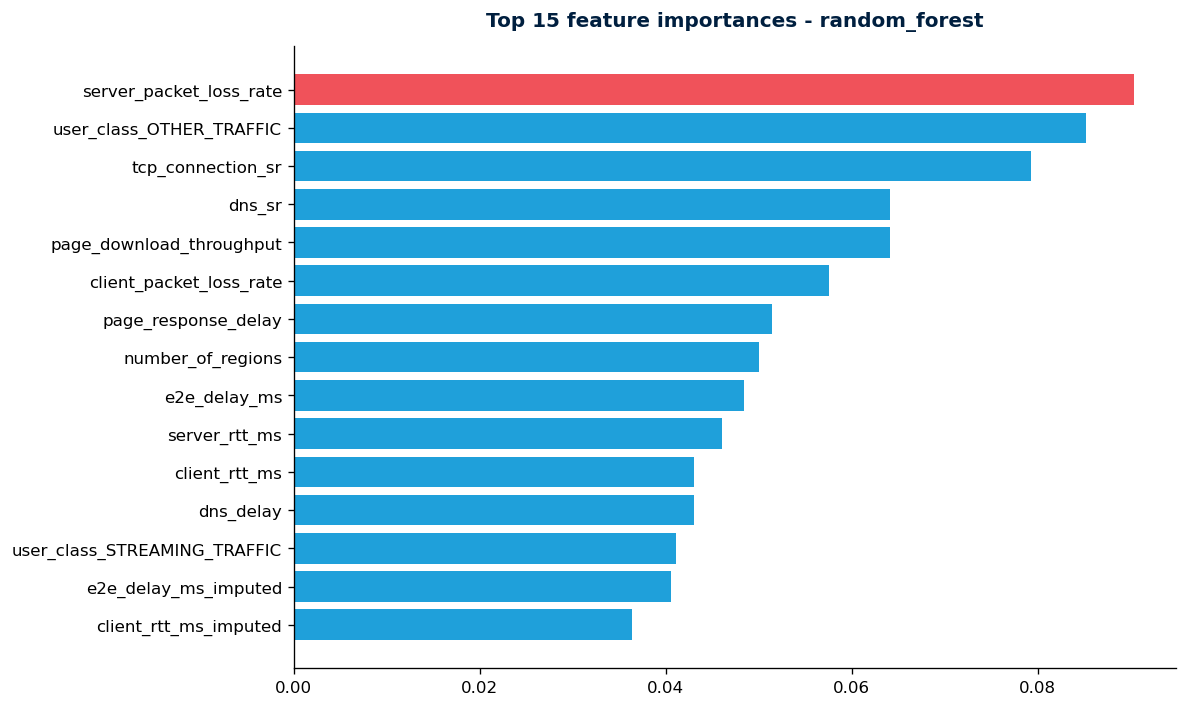

server_packet_loss_rate         0.0904
user_class_OTHER_TRAFFIC        0.0852
tcp_connection_sr               0.0793
dns_sr                          0.0641
page_download_throughput        0.0641
client_packet_loss_rate         0.0576
page_response_delay             0.0514
number_of_regions               0.0501
e2e_delay_ms                    0.0484
server_rtt_ms                   0.0460
client_rtt_ms                   0.0431
dns_delay                       0.0430
user_class_STREAMING_TRAFFIC    0.0411
e2e_delay_ms_imputed            0.0406
client_rtt_ms_imputed           0.0363


In [7]:
# ── Global feature importance analysis (model-level interpretability) ─────
# This section provides a first-order approximation of feature influence
# on disengagement prediction for the selected best-performing model.
#
# Note: This is NOT SHAP analysis (which provides local + global consistency).
# This step gives a global, aggregated view of feature contribution.

best_model = fitted[best_name]

# ── Feature importance extraction depending on model type ────────────────
# Different models encode "importance" differently:
#   - XGBoost / Random Forest → impurity-based importance (split gain proxy)
#   - Logistic Regression      → absolute coefficient magnitude (linear effect size)
#
# These are not directly comparable across models but are internally consistent.

if best_name == 'xgboost':
    imp = pd.Series(best_model.feature_importances_, index=FEATURES)

elif best_name == 'random_forest':
    imp = pd.Series(best_model.named_steps['rf'].feature_importances_,
                    index=FEATURES)

else:
    imp = pd.Series(np.abs(best_model.named_steps['lr'].coef_[0]),
                    index=FEATURES)

# ── Top-K feature selection ─────────────────────────────────────────────
# We focus on the top 15 drivers to highlight dominant explanatory signals.
top = imp.sort_values(ascending=True).tail(15)

# ── Visualization ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Highlight most influential feature for interpretability emphasis
bar_c = [HW['red'] if v == top.max() else HW['blue'] for v in top]

ax.barh(top.index, top.values, color=bar_c, alpha=0.88)

ax.set_title(f'Top 15 feature importances - {best_name}',
             pad=12, color=HW['navy'], fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_02_feature_importance.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ── Tabular interpretation output ───────────────────────────────────────
print(top.sort_values(ascending=False).round(4).to_string())

## 7 — Save artifacts for the FastAPI layer

In [8]:
best = test_results[best_name]
joblib.dump(fitted[best_name], MODEL_DIR / 'disengagement_model_v6.joblib')
json.dump(FEATURES, open(MODEL_DIR / 'disengagement_features.json', 'w'))

# NB05-FIX-2a: score ALL labelled customers (train + test), not just
# the 642-customer test split. The dashboard churn-risk table and the
# notifications scanner need scores for the full 2,566-customer labelled
# population. Applying a fitted model to its own training data is standard
# production scoring — any optimism bias is small for a 400-tree RF.
# The 'split' column is retained so consumers can distinguish if needed.
_all_lab  = df.dropna(subset=['churn'])
_proba_all = fitted[best_name].predict_proba(_all_lab[FEATURES])[:, 1]
risk = pd.DataFrame({
    'msisdn': _all_lab['msisdn'].values,
    'risk'  : np.round(_proba_all, 4),
    'split' : _all_lab['split'].values,       # 'train' | 'test'
    'churn' : _all_lab['churn'].astype(int).values,
})
risk['risk_band'] = pd.cut(risk['risk'], [0, .33, .66, 1.0],
                           labels=['low', 'medium', 'high'],
                           include_lowest=True)
risk_sorted = risk.sort_values('risk', ascending=False)
risk_sorted.to_parquet(MODEL_DIR / 'disengagement_risk_scores.parquet',
                       index=False)

# NB05-FIX-2b: also save to data/outputs/risk_scores_v2.parquet so the
# notifications_api scanner (reads risk_scores_v2.parquet) and any other
# API code expecting the legacy filename find the updated scores without
# needing code changes.
risk_sorted.to_parquet(OUT_DIR / 'risk_scores_v2.parquet', index=False)
print(f'Risk scores: {len(risk):,} customers '
      f'({int((risk.split=="train").sum()):,} train + '
      f'{int((risk.split=="test").sum()):,} test)')
print(f'  -> models/disengagement_risk_scores.parquet')
print(f'  -> data/outputs/risk_scores_v2.parquet  (API compatibility)')

metrics_json = {
    'generated_at' : datetime.now().isoformat(),
    'label_version': 'v6 (disengagement segmentation - see churn_eda_v6.json)',
    'selected_model': best_name,
    'selection_rule': 'OOF PR-AUC on train (5-fold), test touched once',
    'baseline_prevalence': prevalence,
    'test_metrics': {k: {m: round(float(v), 4) for m, v in r.items()
                         if not m.startswith('_')}
                     for k, r in test_results.items()},
    'qos_only_ablation': {m: round(float(v), 4) for m, v in ablation.items()},
    'interpretation_guardrails': [
        'is_2g_only is near-deterministic (structural disengagement)',
        'number_of_regions partially proxies activity volume',
        'tcp_connection_sr / dns_sr strength to be validated with data owner',
    ],
    'artifacts': {
        'model'   : str(MODEL_DIR / 'disengagement_model_v6.joblib'),
        'features': str(MODEL_DIR / 'disengagement_features.json'),
        'scores'  : str(MODEL_DIR / 'disengagement_risk_scores.parquet'),
        'scores_legacy': str(OUT_DIR / 'risk_scores_v2.parquet'),
    },
}
jp = OUT_DIR / 'disengagement_model_metrics.json'
json.dump(metrics_json, open(jp, 'w'), indent=2)
print(f'Saved: {jp}')
print(json.dumps({k: v for k, v in metrics_json.items()
                  if k != 'test_metrics'}, indent=2))
print('\nHigh-risk preview (top 10):')
print(risk_sorted.head(10)[['msisdn','risk','split','risk_band']]
      .to_string(index=False))
print('\nNext -> 06: SHAP on the selected model; then sync the dashboard')
print('(Forecasting TRAINING constant + churn tiles wording).')


Risk scores: 2,566 customers (1,924 train + 642 test)
  -> models/disengagement_risk_scores.parquet
  -> data/outputs/risk_scores_v2.parquet  (API compatibility)
Saved: data\outputs\disengagement_model_metrics.json
{
  "generated_at": "2026-06-30T09:34:15.642377",
  "label_version": "v6 (disengagement segmentation - see churn_eda_v6.json)",
  "selected_model": "random_forest",
  "selection_rule": "OOF PR-AUC on train (5-fold), test touched once",
  "baseline_prevalence": 0.33835758835758833,
  "qos_only_ablation": {
    "roc_auc": 0.8058,
    "pr_auc": 0.7945,
    "f1": 0.7268
  },
  "interpretation_guardrails": [
    "is_2g_only is near-deterministic (structural disengagement)",
    "number_of_regions partially proxies activity volume",
    "tcp_connection_sr / dns_sr strength to be validated with data owner"
  ],
  "artifacts": {
    "model": "models\\disengagement_model_v6.joblib",
    "features": "models\\disengagement_features.json",
    "scores": "models\\disengagement_risk_score